In [58]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [59]:
df = pd.read_csv(r"C:\Users\abhinandan\Desktop\Machine_learning_full\kmeans\Mall_Customers (1).csv")

In [60]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [61]:
df.drop(columns="CustomerID",inplace=True)

In [62]:
select = ["Age", "Annual Income (k$)" ,"Spending Score (1-100)"]

data_c = df[select]

In [63]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()
scaler = scale.fit_transform(data_c)


In [65]:
from scipy.cluster import hierarchy
z = hierarchy.linkage(scaler,method="ward")

In [71]:
labels = fcluster(z, t=2, criterion='maxclust')

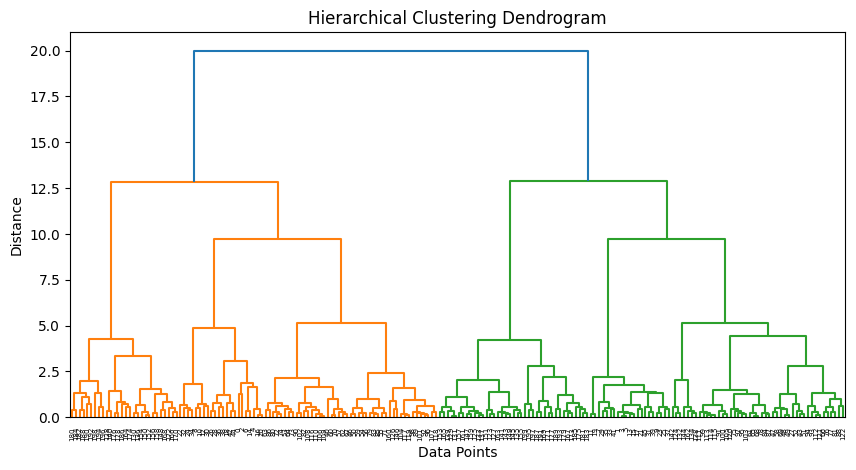

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
hierarchy.dendrogram(z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

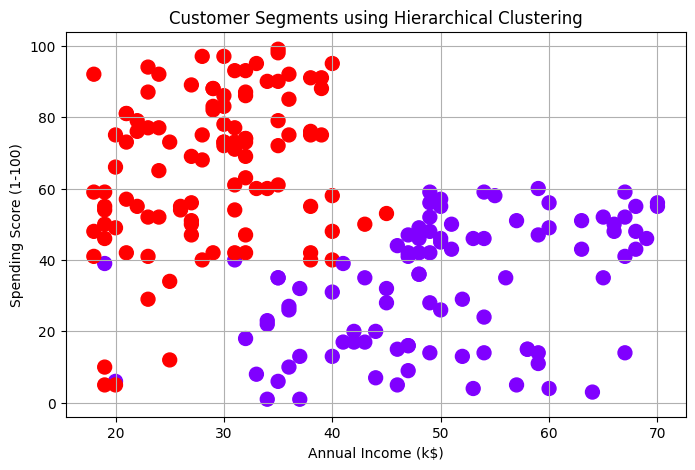

In [72]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Age'], df['Spending Score (1-100)'], c=labels, cmap='rainbow', s=100)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using Hierarchical Clustering")
plt.grid(True)
plt.show()

In [46]:
from sklearn.cluster import KMeans

In [47]:
wcss = []
for i in range(1, 11): 
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaler)
    wcss.append(kmeans.inertia_)

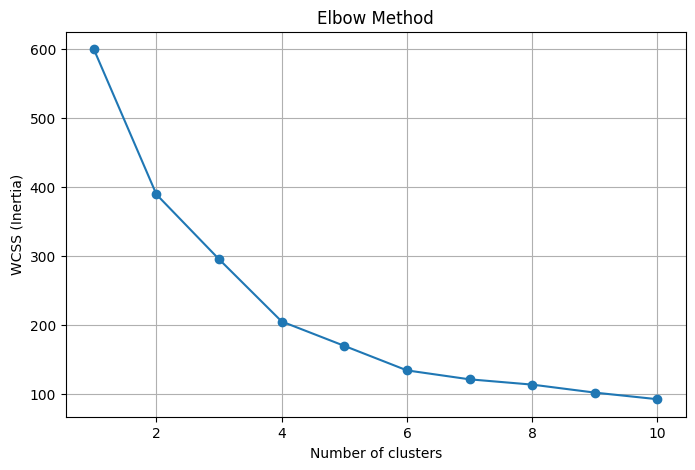

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)
plt.show()

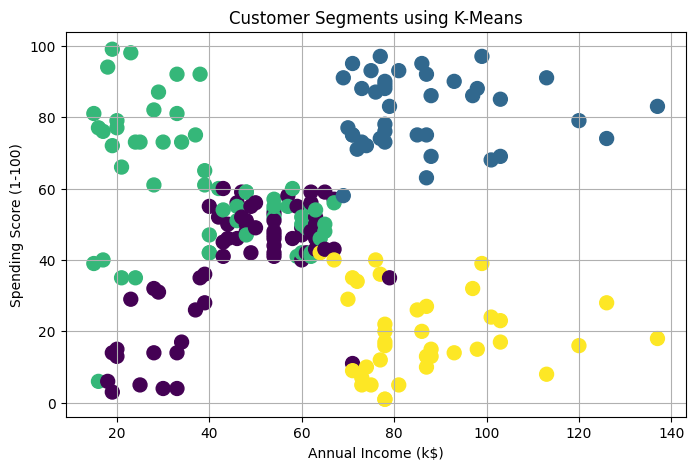

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = pd.read_csv(r"C:\Users\abhinandan\Desktop\Machine_learning_full\kmeans\Mall_Customers (1).csv")

X = data[["Age", 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans.fit(X_scaled)

data['Cluster'] = kmeans.labels_

plt.figure(figsize=(8, 5))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'],
            c=data['Cluster'], cmap='rainbow', s=100)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using K-Means")
plt.grid(True)
plt.show()


In [77]:
from scipy.cluster.hierarchy import fcluster

In [78]:
df["clusters"] = fcluster(z,t=5,criterion='maxclust')

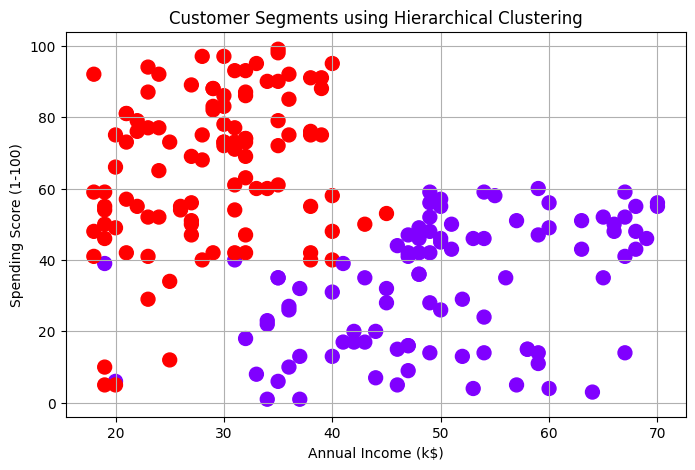

In [79]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Age'], df['Spending Score (1-100)'], c=labels, cmap='rainbow', s=100)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using Hierarchical Clustering")
plt.grid(True)
plt.show()